## Health Risk (Target Identify Medical Condition)

Imports

In [163]:
import pandas as pd
import numpy as np
import kagglehub
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve

Downloading Dataset from Kagglehub

In [164]:
path = kagglehub.dataset_download("abdallaahmed77/healthcare-risk-factors-dataset")
print("Path to dataset files:", path)
dataset="dirty_v3_path.csv"
full_path=os.path.join(path,dataset)
print(full_path)

Path to dataset files: C:\Users\Youssef Haitham\.cache\kagglehub\datasets\abdallaahmed77\healthcare-risk-factors-dataset\versions\1
C:\Users\Youssef Haitham\.cache\kagglehub\datasets\abdallaahmed77\healthcare-risk-factors-dataset\versions\1\dirty_v3_path.csv


In [165]:
df=pd.read_csv(full_path)
df.head()

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours,random_notes,noise_col
0,46.0,Male,Diabetes,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05,lorem,-137.057211
1,22.0,Male,Healthy,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72,ipsum,-11.230610
2,50.0,NaN,Asthma,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82,ipsum,98.331195
3,57.0,NaN,Obesity,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33,lorem,44.187175
4,66.0,Female,Hypertension,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64,lorem,44.831426


In [166]:
#nulls
df.isnull().sum()

Age                  4500
Gender               4500
Medical Condition    4500
Glucose              4500
Blood Pressure       4500
BMI                     0
Oxygen Saturation       0
LengthOfStay            0
Cholesterol             0
Triglycerides           0
HbA1c                   0
Smoking                 0
Alcohol                 0
Physical Activity       0
Diet Score              0
Family History          0
Stress Level            0
Sleep Hours             0
random_notes            0
noise_col               0
dtype: int64

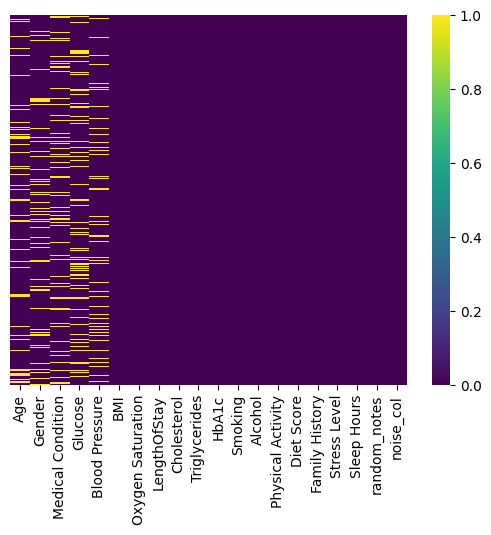

In [167]:
#showing NULLS
sns.heatmap(df.isnull(),yticklabels=False,cmap='viridis')
plt.show()

Removing Medical Condition NULLS since that is my target and I can't have NULLS in my target feature

4500
0


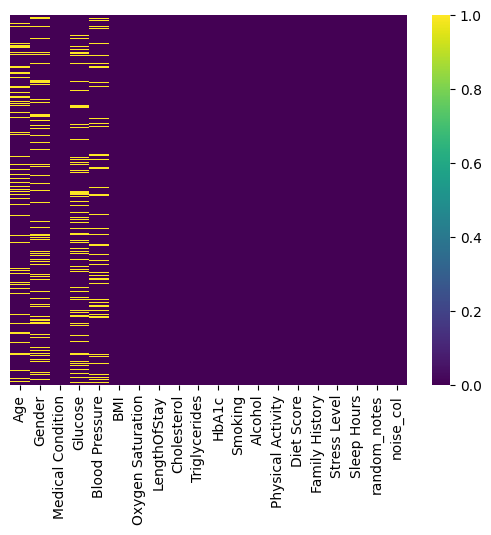

In [168]:
print(df['Medical Condition'].isna().sum())
df=df.dropna(subset=['Medical Condition'])
print(df['Medical Condition'].isna().sum())
sns.heatmap(df.isnull(),yticklabels=False,cmap='viridis')
plt.show()

Since Gender is not Numerical it would be better just to label the Gender as Unknown

In [169]:
print(df['Gender'].isna().sum(),"/",df['Gender'].count(),"=", df['Gender'].isna().sum()/df['Gender'].count()*100)
df['Gender']=df['Gender'].fillna('Unknown')
print(df['Gender'].isna().sum())

3794 / 21706 = 17.479038053994287
0


## Label Enconding

In [170]:
label_enc = LabelEncoder()
df['Medical Condition'] = label_enc.fit_transform(df['Medical Condition'])
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])

In [171]:
df=df.drop(columns='random_notes')
df=df.drop(columns="noise_col")
df

,Age,Gender,Medical Condition,Glucose,Blood Pressure,BMI,Oxygen Saturation,LengthOfStay,Cholesterol,Triglycerides,HbA1c,Smoking,Alcohol,Physical Activity,Diet Score,Family History,Stress Level,Sleep Hours
0,46.0,1,3,137.04,135.27,28.90,96.04,6,231.88,210.56,7.61,0,0,-0.20,3.54,0,5.07,6.05
1,22.0,1,4,71.58,113.27,26.29,97.54,2,165.57,129.41,4.91,0,0,8.12,5.90,0,5.87,7.72
2,50.0,2,1,95.24,NaN,22.53,90.31,2,214.94,165.35,5.60,0,0,5.01,4.65,1,3.09,4.82
3,57.0,2,6,NaN,130.53,38.47,96.60,5,197.71,182.13,6.92,0,0,3.16,3.37,0,3.01,5.33
4,66.0,0,5,95.15,178.17,31.12,94.90,4,259.53,115.85,5.98,0,1,3.56,3.40,0,6.38,6.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29994,76.0,2,5,97.17,138.92,25.65,93.99,3,235.65,238.26,6.43,0,0,3.14,3.46,0,6.66,6.10
29995,54.0,0,4,86.35,127.68,28.30,94.36,1,218.60,152.82,4.85,0,0,9.15,10.35,0,3.65,8.71
29996,41.0,1,1,89.24,154.37,24.93,96.07,4,198.30,176.81,5.36,1,0,3.34,3.40,0,6.72,2.81
29998,41.0,1,3,242.87,152.97,23.57,99.17,3,208.86,224.21,7.59,0,0,3.16,2.59,0,7.10,5.80


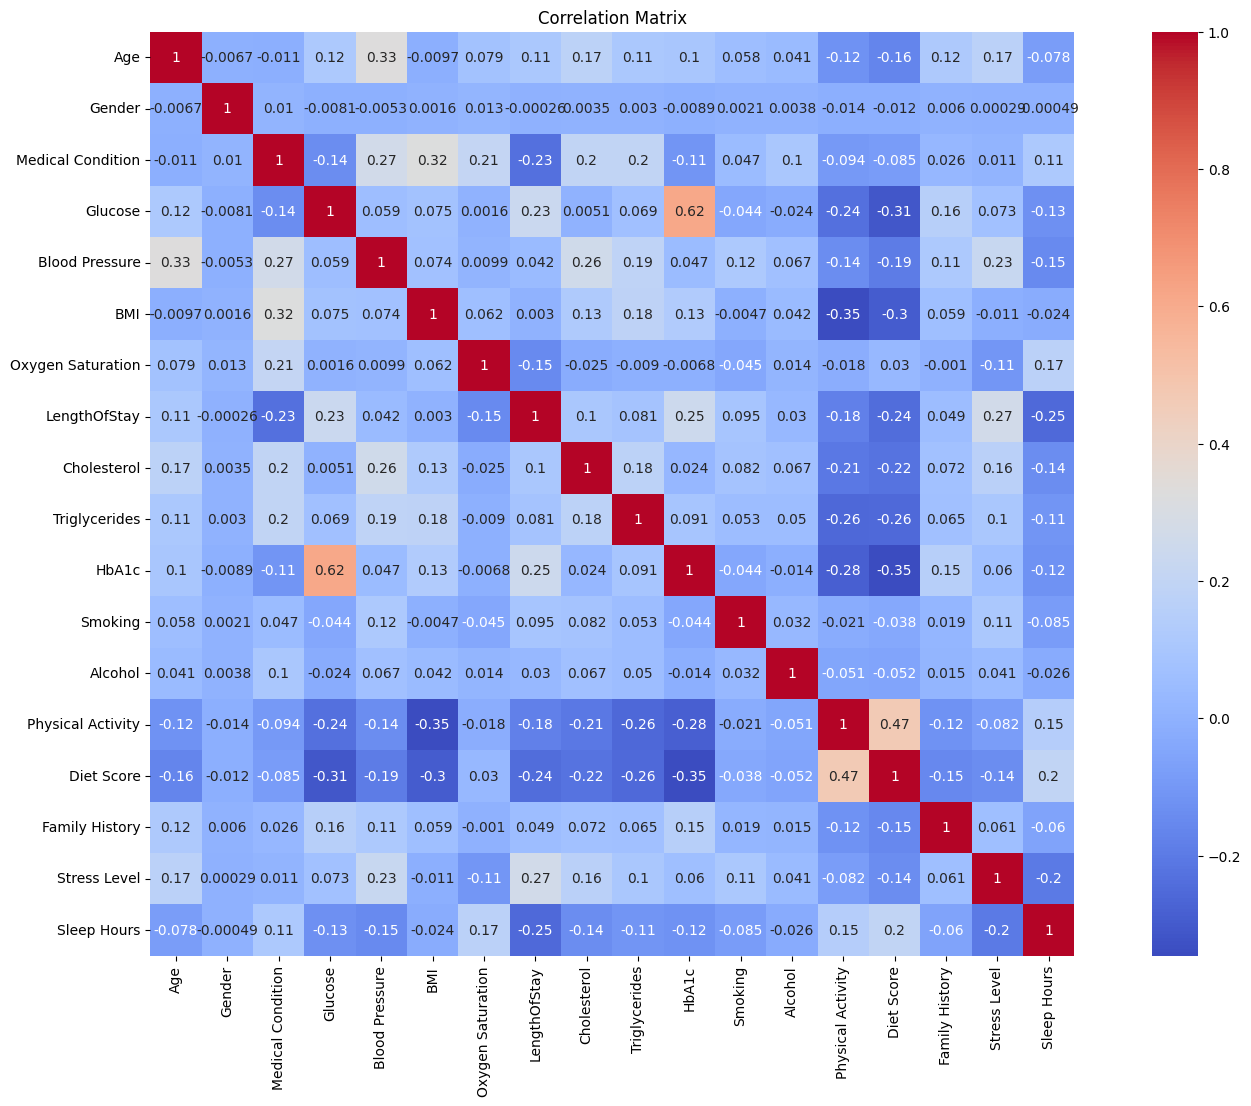

In [172]:
corr=df.corr()
plt.figure(figsize=(20,12))
sns.heatmap(corr,annot=True,cmap="coolwarm",square=True)
plt.title("Correlation Matrix")
plt.show()

Dropping Random, useless or nulls

Before dealing with nulls I must first understand my data these visualisations will help me understand my data

In [173]:
df.dtypes

Age                  float64
Gender                 int64
Medical Condition      int64
Glucose              float64
Blood Pressure       float64
BMI                  float64
Oxygen Saturation    float64
LengthOfStay           int64
Cholesterol          float64
Triglycerides        float64
HbA1c                float64
Smoking                int64
Alcohol                int64
Physical Activity    float64
Diet Score           float64
Family History         int64
Stress Level         float64
Sleep Hours          float64
dtype: object

I need to know how the data is distributed to know whether to remove the data or fill it and if I were to fill it would I use mean or median

In [174]:
print(df['Glucose'].isna().sum(),df['Blood Pressure'].isna().sum())

3788 3800


As seen above the NULLS are not so small as to be removed but not too big as to cause an impact so filling them was the right choice

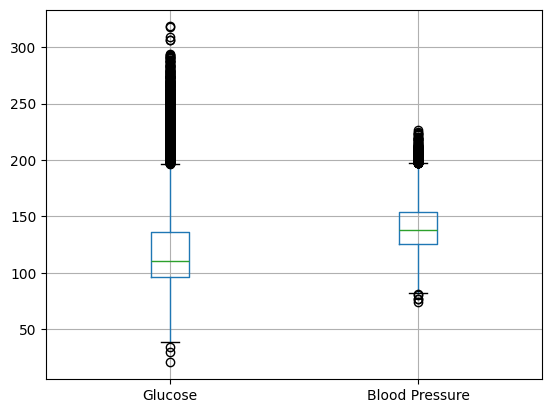

In [175]:
df[['Glucose','Blood Pressure']].boxplot()
plt.show()

The box plot shows a lot of outliers meaning that the mean would be inaccurate here and the median would be better

In [176]:
df=df.copy()
print(df['Glucose'].isna().sum(),df['Blood Pressure'].isna().sum())
medianGL=df['Glucose'].median()
medianBP=df['Blood Pressure'].median()
df['Glucose']=df['Glucose'].fillna(medianGL)
df['Blood Pressure']=df['Blood Pressure'].fillna(medianBP)
print(df['Glucose'].isna().sum(),df['Blood Pressure'].isna().sum())

3788 3800
0 0


Age is Numerical and the Distribution is close to a bell shape meaning also median was ideal here

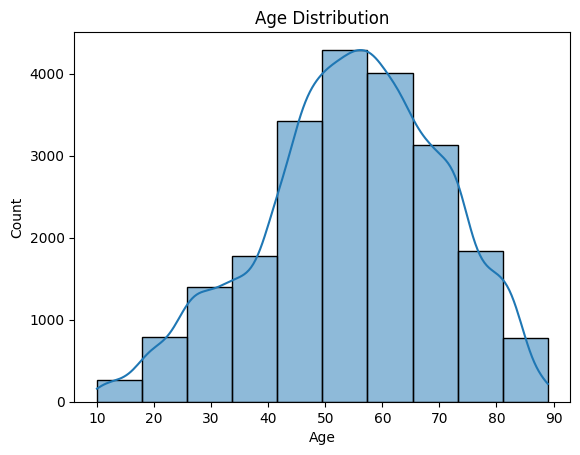

In [177]:
sns.histplot(df['Age'], bins=10, kde=True)
plt.xlabel('Age')
plt.title('Age Distribution')
plt.show()

In [178]:
df=df.copy()
print(df['Age'].isna().sum())
medianA=df['Age'].median()
df['Age']=df['Age'].fillna(medianA)
print(df['Age'].isna().sum())

3821
0


Results after cleaning out NULLS

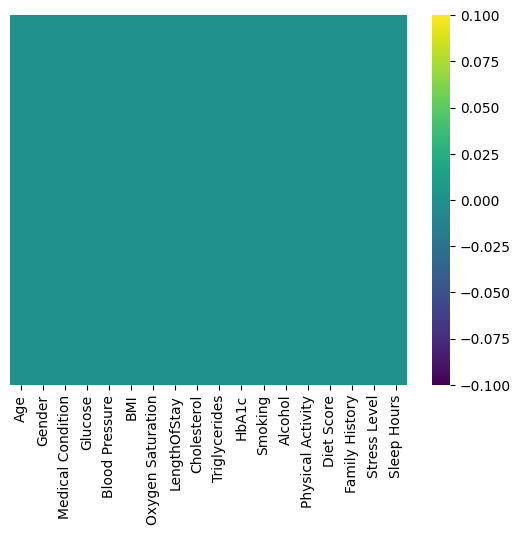

In [179]:
sns.heatmap(df.isnull(),yticklabels=False,cmap='viridis')
plt.show()

## Classification Time

Train/ Test Split

In [180]:
X = df.drop('Medical Condition', axis=1)
y = df['Medical Condition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scaling

In [181]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Classification Models

Logistic Regression

In [182]:
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

F1 Score Logistic Regression

	Logistic Regression
F1 Score: 0.9031
              precision    recall  f1-score   support

   Arthritis       0.74      0.61      0.67       359
      Asthma       0.91      0.92      0.92       407
      Cancer       0.98      0.95      0.96       247
    Diabetes       0.95      0.94      0.95      1284
     Healthy       0.98      0.99      0.99       608
Hypertension       0.86      0.90      0.88      1424
     Obesity       0.89      0.88      0.88       771

    accuracy                           0.90      5100
   macro avg       0.90      0.89      0.89      5100
weighted avg       0.90      0.90      0.90      5100



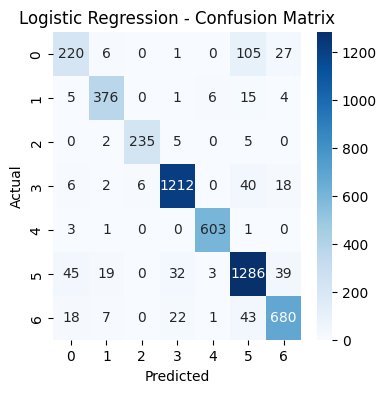

In [183]:
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
print("\tLogistic Regression")
print(f"F1 Score: {lr_f1:.4f}")
print(classification_report(y_test, lr_pred, target_names=label_enc.classes_))

plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Learning Curve

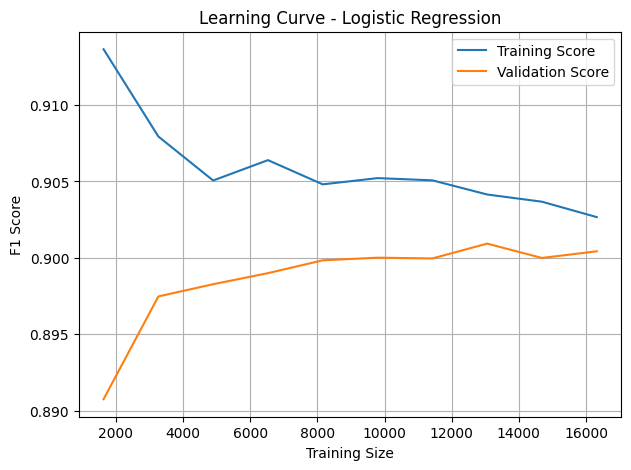

In [184]:
train_sizes, train_scores, test_scores = learning_curve(
    lr_model,       # your Logistic Regression model
    X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.grid()
plt.show()


SVM

In [185]:
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

F1 Score SVM

	Support Vector Machine
F1 Score: 0.9132
              precision    recall  f1-score   support

   Arthritis       0.77      0.67      0.71       359
      Asthma       0.93      0.92      0.93       407
      Cancer       0.98      0.95      0.97       247
    Diabetes       0.96      0.94      0.95      1284
     Healthy       0.99      1.00      0.99       608
Hypertension       0.88      0.92      0.90      1424
     Obesity       0.89      0.90      0.89       771

    accuracy                           0.91      5100
   macro avg       0.91      0.90      0.91      5100
weighted avg       0.91      0.91      0.91      5100



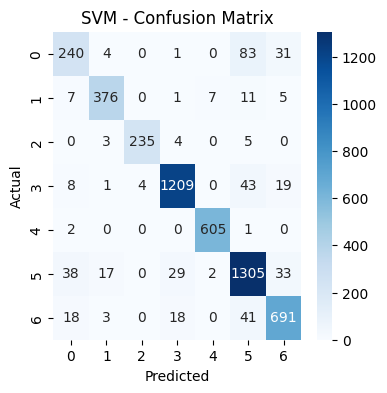

In [186]:
svm_f1 = f1_score(y_test, svm_pred, average='weighted')
print("\tSupport Vector Machine")
print(f"F1 Score: {svm_f1:.4f}")
print(classification_report(y_test, svm_pred, target_names=label_enc.classes_))

plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Learning Curve

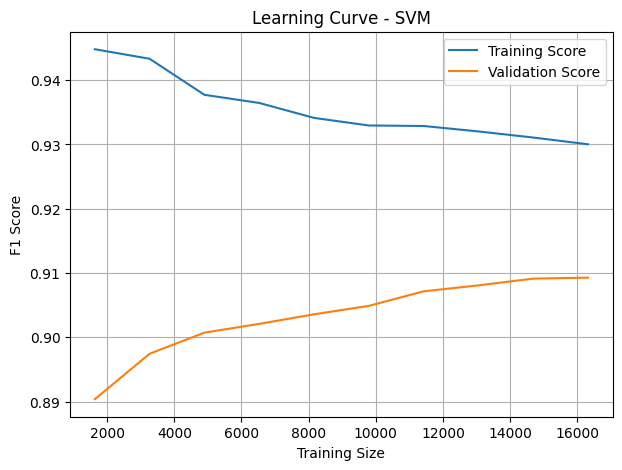

In [187]:
train_sizes, train_scores, test_scores = learning_curve(
    svm_model,      # your SVM model (SVC with probability=True)
    X_train_scaled, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted',
    n_jobs=-1       # use all CPU cores
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve - SVM")
plt.legend()
plt.grid()
plt.show()


Decision Tree

In [188]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=9, min_samples_split=50,min_samples_leaf=40)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

F1 Score Decision Tree

	Decision Tree
F1 Score: 0.8314
              precision    recall  f1-score   support

   Arthritis       0.41      0.59      0.48       359
      Asthma       0.83      0.69      0.75       407
      Cancer       0.96      0.85      0.90       247
    Diabetes       0.95      0.89      0.92      1284
     Healthy       0.93      0.94      0.93       608
Hypertension       0.79      0.86      0.82      1424
     Obesity       0.86      0.75      0.80       771

    accuracy                           0.83      5100
   macro avg       0.82      0.79      0.80      5100
weighted avg       0.84      0.83      0.83      5100



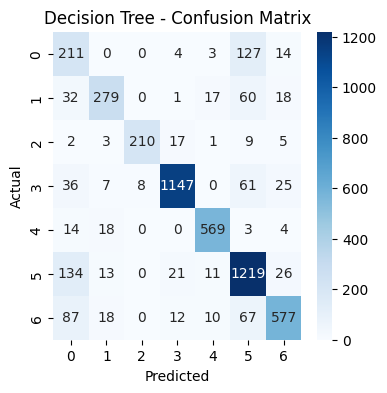

In [189]:
dt_f1 = f1_score(y_test, dt_pred, average='weighted')
print("\tDecision Tree")
print(f"F1 Score: {dt_f1:.4f}")
print(classification_report(y_test, dt_pred, target_names=label_enc.classes_))

plt.figure(figsize=(4,4))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Learning Curve

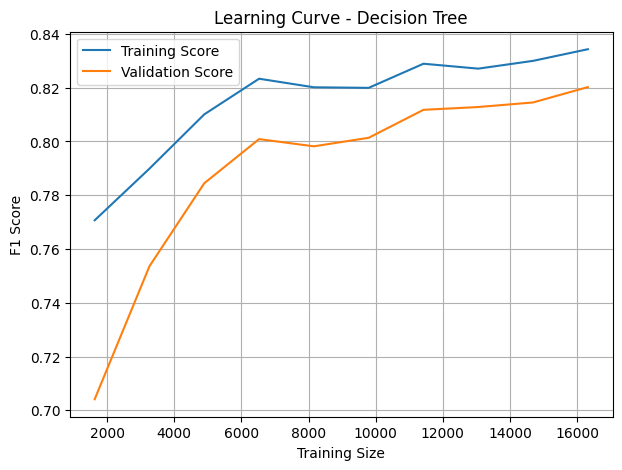

In [190]:
train_sizes, train_scores, test_scores = learning_curve(
    dt_model,       # your trained Decision Tree model
    X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_weighted'
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, test_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve - Decision Tree")
plt.legend()
plt.grid()
plt.show()

F1 Scores Comparison

	F1 Score Comparison
                 Model  F1 Score
0        Decision Tree  0.831433
1  Logistic Regression  0.903083
2                  SVM  0.913231


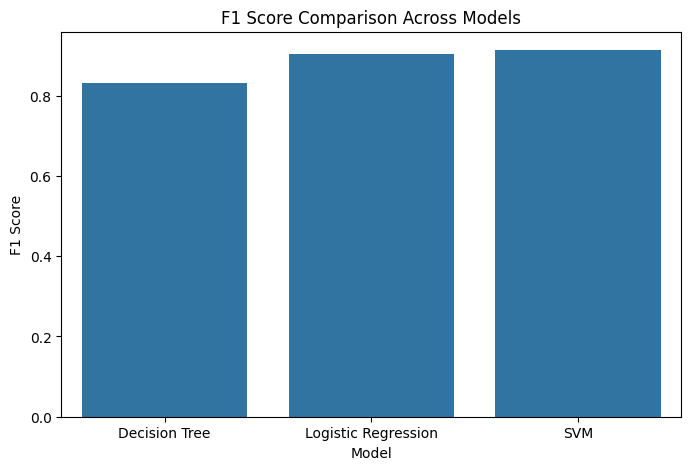

In [191]:
f1_scores = {
    "Decision Tree": dt_f1,
    "Logistic Regression": lr_f1,
    "SVM": svm_f1
}
f1_df = pd.DataFrame(list(f1_scores.items()), columns=["Model", "F1 Score"])
print("\tF1 Score Comparison")
print(f1_df)

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1 Score", data=f1_df)
plt.title("F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.show()